In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import torch
from models.linear_probes import linear_probe, linear_probe_tuned
from models.feature_generation import build_feature_bank, extract_encoder, extract_feature,pool_features
from preprocessing.dataset import PipistrelleDataset
from evaluation.metrics import compute_cv_stats,plot_model_comparison,label_confusion
import pandas as pd
from sklearn.metrics import average_precision_score
from evaluation.metrics import compute_metrics,compile_results,generate_metrics_table2,plot_comprehensive_boxplots
from evaluation.metrics import plot_comprehensive_calibration
from models.MLP_balancing import balancing_mlp
import pickle
from pathlib import Path
import os
from evaluation.statistical_tests import perform_encoder_statistical_analysis

c:\Users\artem\AppData\Local\miniconda3\envs\playground\lib\site-packages\google\api_core\_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
c:\Users\artem\AppData\Local\miniconda3\envs\playground\lib\site-packages\google\api_core\_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.cloud.storage_control_v2 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.storage_control_v2 past that date.
  warnings.warn(message, FutureWarning)
c:\Users\artem\AppData\Local\m

In [4]:

#Testing feature extraction (without echo)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
encoder = "perch2"
encoder_model = extract_encoder(encoder)
dir = Path(os.getcwd()).resolve().parent / "data"
batdata = PipistrelleDataset(data_input=str(dir / "bat_metadata.csv"),
                             root_dir=str(dir / "xenocanto-dataset"),
                             encoder = encoder,
                             filter_echo = True)

features,labels = build_feature_bank(batdata, encoder_model, encoder, device=device)
print(len(features))
pooled_feats = pool_features(features,windows= True ,window_pooled = False, method ='mean',encoder = encoder)
print(pooled_feats.shape)
npz_file_path = 'perch2-2-noecho-2.npz'
np.savez(str(npz_file_path), pooled_feats=pooled_feats, labels=labels)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
encoder = "NLM_BEATs"
encoder_model = extract_encoder(encoder)
dir = Path(os.getcwd()).resolve().parent / "data"
batdata = PipistrelleDataset(data_input=str(dir / "bat_metadata.csv"),
                             root_dir=str(dir / "xenocanto-dataset"),
                             encoder = encoder,
                             filter_echo = True)

features,labels = build_feature_bank(batdata, encoder_model, encoder, device=device)
print(len(features))
pooled_feats = pool_features(features,windows= True ,window_pooled = False, method ='mean',encoder = encoder)
print(pooled_feats.shape)
npz_file_path = 'NLM_BEATs-2-noecho-2.npz'
np.savez(str(npz_file_path), pooled_feats=pooled_feats, labels=labels)

#Testing feature extraction (without echo)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
encoder = "effnetb0"
encoder_model = extract_encoder(encoder)
dir = Path(os.getcwd()).resolve().parent / "data"
batdata = PipistrelleDataset(data_input=str(dir / "bat_metadata.csv"),
                             root_dir=str(dir / "xenocanto-dataset"),
                             encoder = encoder,
                             filter_echo = True)

features,labels = build_feature_bank(batdata, encoder_model, encoder, device=device)
print(len(features))
pooled_feats = pool_features(features,windows= True ,window_pooled = False, method ='mean',encoder = encoder)
print(pooled_feats.shape)
npz_file_path = 'AVEX-effnetb0-2-noecho-2.npz'
np.savez(str(npz_file_path), pooled_feats=pooled_feats, labels=labels)

Dataset type: <class 'preprocessing.dataset.PipistrelleDataset'>


Extracting perch2: 100%|██████████| 284/284 [27:19<00:00,  5.77s/it]


284
(284, 16, 4, 1536)
Dataset type: <class 'preprocessing.dataset.PipistrelleDataset'>


Extracting NLM_BEATs: 100%|██████████| 284/284 [1:09:24<00:00, 14.66s/it]


284
(284, 496, 768)
Dataset type: <class 'preprocessing.dataset.PipistrelleDataset'>


Extracting effnetb0: 100%|██████████| 284/284 [09:40<00:00,  2.04s/it]


284
(284, 1280, 4, 32)


In [17]:
dir = Path(os.getcwd()).resolve().parent 
path = str(dir / "models" / "features")
X_eff0 = np.load(path + "\\AVEX-effnetb0-2-noecho-2.npz")['pooled_feats']
X_NLM = np.load(path + "\\NLM_BEATs-2-noecho-2.npz")['pooled_feats']
X_per2 = np.load(path + "\\perch2-2-noecho-2.npz")['pooled_feats']
y = np.load(path + "\\perch2-2-noecho-2.npz")['labels']
label_names = ['Type A', 'Type B', 'Type C', 'Type D', 'Echo']

In [18]:
X_eff0_pooled = pool_features(X_eff0, windows=False, window_pooled=True, method='mean',encoder="effnetb0")
X_NLM_pooled = pool_features(X_NLM, windows=False, window_pooled=True, method='mean',encoder="NLM_BEATs")
X_per2_pooled = pool_features(X_per2, windows=False, window_pooled=True, method='mean',encoder="perch2")

In [19]:
print(X_eff0_pooled.shape)

(284, 1280)


In [21]:
# Create a mask: True where the row does NOT match [0, 0, 0, 0, 1]
X_eff0_arr = np.array(X_eff0_pooled)
X_NLM_arr  = np.array(X_NLM_pooled)
X_per2_arr = np.array(X_per2_pooled)
y_arr      = np.array(y)
mask = ~np.all(y_arr == [0, 0, 0, 0, 1], axis=1)

# Apply the mask to filter out those indices
X_eff0_pooled = X_eff0_arr[mask] # Remove .tolist() if you prefer keeping them as arrays
X_NLM_pooled  = X_NLM_arr[mask]
X_per2_pooled = X_per2_arr[mask]
y             = y_arr[mask]

In [25]:
print(X_eff0_pooled.shape)
print(y[:,:4].shape)

(233, 1280)
(233, 4)


In [26]:
eff0_all_results = linear_probe_tuned(X_eff0_pooled, y[:,:4], n_split_out=5,n_split_in=5, num_trials=5,random_state=42)

Starting Trial 1/5 with random_state=42...
  Tuning and evaluating model: SVM
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: Logistic Regression
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: Random Forest
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: MLP
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: Prevalence guesser
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
Starting Trial 2/5 with random_state=43...
  Tuning and evaluating model: SVM
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating 

In [27]:
per2_all_results =linear_probe_tuned(X_per2_pooled,y[:,:4], n_split_out=5,n_split_in=5, num_trials=5,random_state=42)

Starting Trial 1/5 with random_state=42...
  Tuning and evaluating model: SVM
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: Logistic Regression
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: Random Forest
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: MLP
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: Prevalence guesser
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
Starting Trial 2/5 with random_state=43...
  Tuning and evaluating model: SVM
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating 

In [28]:
NLM_all_results =linear_probe_tuned(X_NLM_pooled, y[:,:4], n_split_out=5,n_split_in=5, num_trials=5,random_state=42)

Starting Trial 1/5 with random_state=42...
  Tuning and evaluating model: SVM
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: Logistic Regression
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: Random Forest
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: MLP
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: Prevalence guesser
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
Starting Trial 2/5 with random_state=43...
  Tuning and evaluating model: SVM
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating 

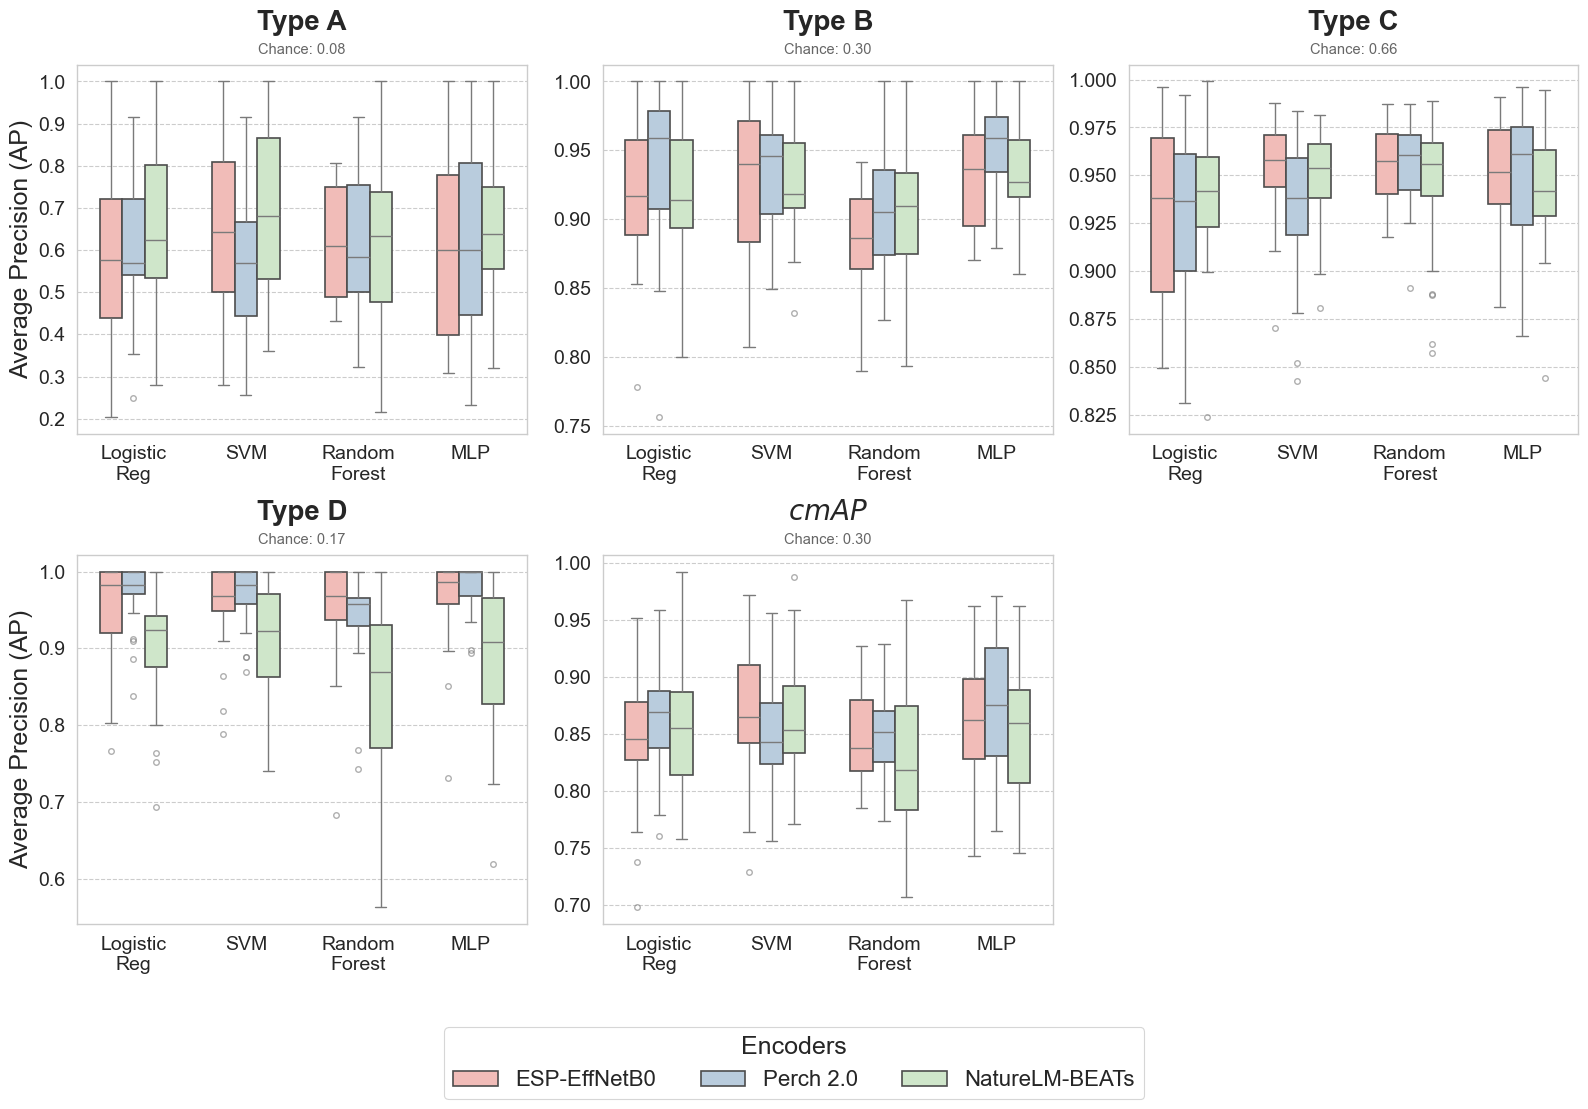

In [38]:
label_names = ['Type A', 'Type B', 'Type C', 'Type D']

results_test = {
            'ESP-EffNetB0': eff0_all_results,
            'Perch 2.0': per2_all_results,
            'NatureLM-BEATs': NLM_all_results
        }

from evaluation.metrics import plot_comprehensive_boxplots_no_echo
plot_comprehensive_boxplots_no_echo(results_test, label_names=label_names)

In [39]:
df_stat = perform_encoder_statistical_analysis(results_test, label_names=label_names)

=== Statistical Setup ===
Number of perfectly matched Blocks (N): 400
Treatments (Encoders mapped): ['ESP-EffNetB0', 'Perch 2.0', 'NatureLM-BEATs']

=== Friedman Test Results ===
Friedman $\chi^2$ Statistic: 21.8131
p-value: 1.8338e-05
Result: Significant difference detected (p < 0.05). Proceeding to Post-Hoc Nemenyi Test.

=== Mean Ranks (Lower is Better/Rank 1 is Top) ===
• ESP-EffNetB0: 2.009
• Perch 2.0: 1.834
• NatureLM-BEATs: 2.158

Calculated Nemenyi Critical Difference (CD): 0.2343

=== Nemenyi Pairwise p-value Matrix ===
                ESP-EffNetB0  Perch 2.0  NatureLM-BEATs
ESP-EffNetB0          1.0000     0.0356          0.0891
Perch 2.0             0.0356     1.0000      1.3964e-05
NatureLM-BEATs        0.0891 1.3964e-05          1.0000

*Interpretation: Pairwise cells show exact p-values. If p < 0.05, performance difference is significant.


Friedman test p-value: 1.8338e-05


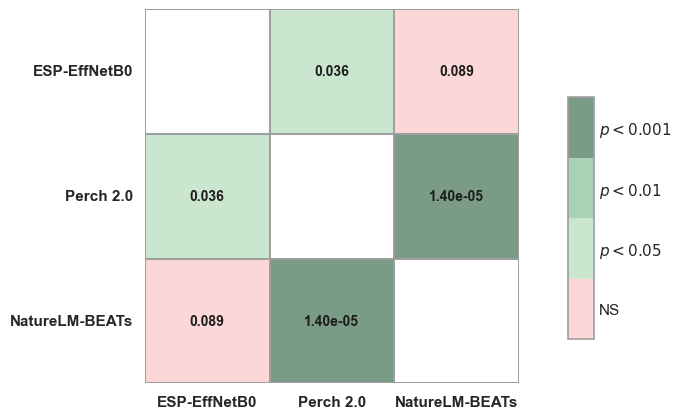

In [40]:
from evaluation.statistical_tests import perform_and_plot_nemenyi
perform_and_plot_nemenyi(results_test, label_names=label_names)

In [43]:
from evaluation.tables import process_encoder_folds_to_table_no_echo
latex_code = process_encoder_folds_to_table_no_echo(results_test)
with open("encoder_table_no_echo.tex", "w", encoding="utf-8") as f:
    f.write(latex_code)

In [ ]:
dir = Path(os.getcwd()).resolve().parent 
path = str(dir / "models" / "features")
X_eff0 = np.load(path + "\\X_features2_not_normalized.npy")
X_NLM = np.load(path + "\\X_features_NLM.npy")
X_per2 = np.load(path + "\\perch_features.npz")['features']
y = np.load(path + "\\Y_labels2_not_normalized.npy")
label_names = ['Type A', 'Type B', 'Type C', 'Type D', 'Echo']

In [4]:
#pooled features
X_eff0_pooled = pool_features(X_eff0, windows=False, window_pooled=True, method='mean',encoder="effnetb0")
X_NLM_pooled = pool_features(X_NLM, windows=False, window_pooled=True, method='mean',encoder="NLM_BEATs")
X_per2_pooled = X_per2

In [9]:
from evaluation.tables import evaluate_avex_multilabel
embedding_dict ={
        'perch': X_per2_pooled,
        'effnetb0': X_eff0_pooled,
        'naturelm-beats': X_NLM_pooled
    }
latex_code =evaluate_avex_multilabel(embedding_dict, y, label_name="tab:encoder_eval")
# 3. Or save it directly to a .tex snippet file to import into your main document
with open("unsupervised_metrics.tex", "w") as f:
    f.write(latex_code)

In [5]:
eff0_all_results = linear_probe_tuned(X_eff0_pooled, y, n_split_out=5,n_split_in=5, num_trials=5,random_state=42)

Starting Trial 1/5 with random_state=42...
  Tuning and evaluating model: SVM
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: Logistic Regression
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: Random Forest
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: MLP
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: Prevalence guesser
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
Starting Trial 2/5 with random_state=43...
  Tuning and evaluating model: SVM
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating 

In [11]:
eff0_all_results2 = linear_probe_tuned(X_eff0_pooled, y, n_split_out=5,n_split_in=5, num_trials=5,random_state=42)

Starting Trial 1/5 with random_state=42...
  Tuning and evaluating model: SVM
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: Logistic Regression
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: Random Forest
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: MLP
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: Prevalence guesser
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
Starting Trial 2/5 with random_state=43...
  Tuning and evaluating model: SVM
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating 

In [6]:
per2_all_results =linear_probe_tuned(X_per2_pooled, y, n_split_out=5,n_split_in=5, num_trials=5,random_state=42)

Starting Trial 1/5 with random_state=42...
  Tuning and evaluating model: SVM
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: Logistic Regression
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: Random Forest
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: MLP
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: Prevalence guesser
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
Starting Trial 2/5 with random_state=43...
  Tuning and evaluating model: SVM
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating 

In [7]:
NLM_all_results =linear_probe_tuned(X_NLM_pooled, y, n_split_out=5,n_split_in=5, num_trials=5,random_state=42)

Starting Trial 1/5 with random_state=42...
  Tuning and evaluating model: SVM
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: Logistic Regression
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: Random Forest
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: MLP
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: Prevalence guesser
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
Starting Trial 2/5 with random_state=43...
  Tuning and evaluating model: SVM
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating 

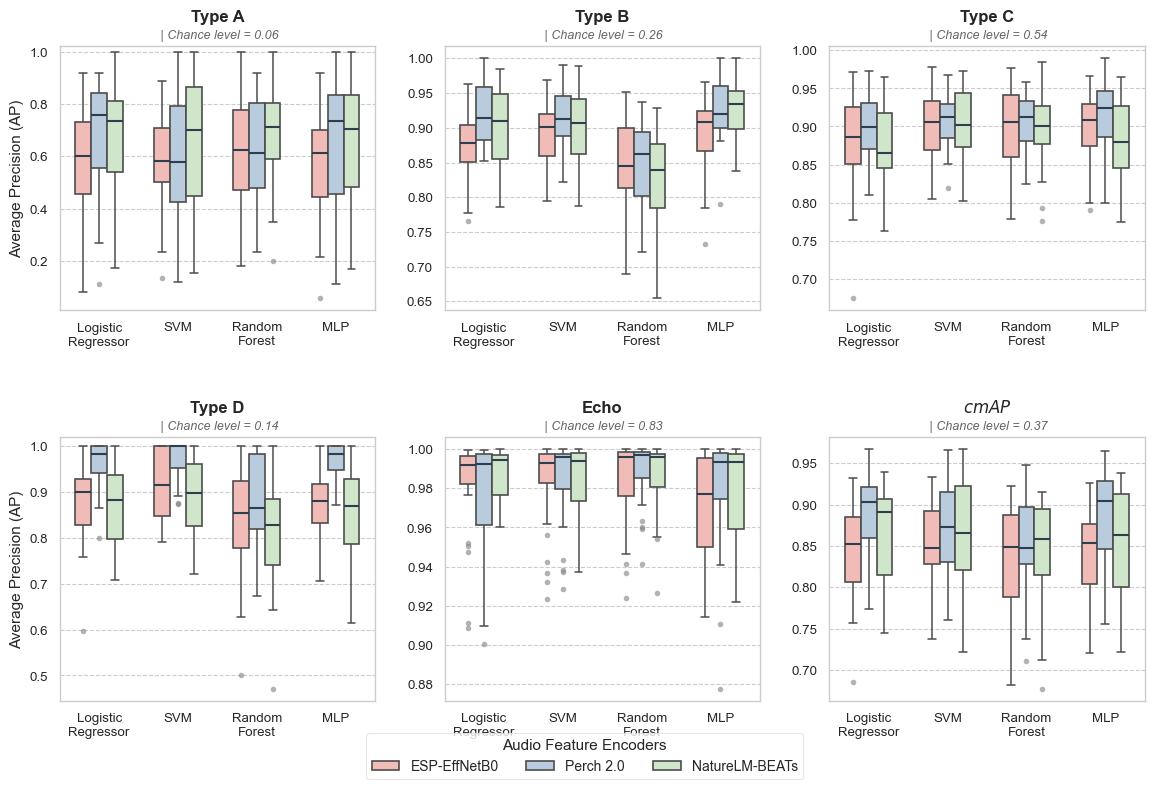

In [28]:
label_names = ['Type A', 'Type B', 'Type C', 'Type D','Echo']

results_test = {
            'ESP-EffNetB0': eff0_all_results,
            'Perch 2.0': per2_all_results,
            'NatureLM-BEATs': NLM_all_results
        }

plot_comprehensive_boxplots(results_test, label_names=label_names)

In [9]:
df_stat = perform_encoder_statistical_analysis(results_test, label_names=label_names)

=== Statistical Setup ===
Number of perfectly matched Blocks (N): 500
Treatments (Encoders mapped): ['ESP-EffNetB0', 'Perch 2.0', 'NatureLM-BEATs']

=== Friedman Test Results ===
Friedman $\chi^2$ Statistic: 68.3622
p-value: 1.4300e-15
Result: Significant difference detected (p < 0.05). Proceeding to Post-Hoc Nemenyi Test.

=== Mean Ranks (Lower is Better/Rank 1 is Top) ===
• ESP-EffNetB0: 2.237
• Perch 2.0: 1.725
• NatureLM-BEATs: 2.038

Calculated Nemenyi Critical Difference (CD): 0.2096

=== Nemenyi Pairwise p-value Matrix ===
                ESP-EffNetB0  Perch 2.0  NatureLM-BEATs
ESP-EffNetB0          1.0000 1.8874e-15          0.0047
Perch 2.0         1.8874e-15     1.0000      2.2312e-06
NatureLM-BEATs        0.0047 2.2312e-06          1.0000

*Interpretation: Pairwise cells show exact p-values. If p < 0.05, performance difference is significant.


Friedman test p-value: 1.4300e-15


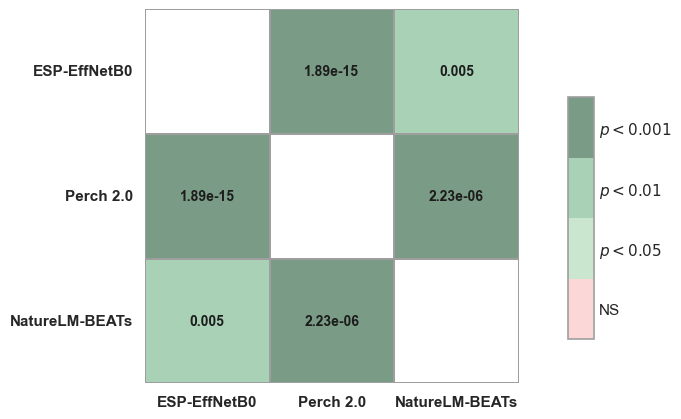

In [10]:
from evaluation.statistical_tests import perform_and_plot_nemenyi
perform_and_plot_nemenyi(results_test, label_names=label_names)

In [24]:
from evaluation.tables import process_encoder_folds_to_table
latex_code = process_encoder_folds_to_table(results_test)
print(latex_code)

\begin{table}[htbp]
\centering
\caption{Comparative performance evaluation across audio embedding encoders and downstream classifiers against a chance-level baseline. Metrics report the mean ($\pm$ standard error of the mean) computed over 25 validation folds, with top values highlighted in bold.}
\label{tab:encoder_results}
\footnotesize
\def\arraystretch{1.2}
\setlength{\tabcolsep}{5pt}
\begin{tabular}{llcccccc}
\toprule
\textbf{Encoder} & \textbf{Classifier} & \textbf{Type A AP} & \textbf{Type B AP} & \textbf{Type C AP} & \textbf{Type D AP} & \textbf{Echo AP} & \textbf{cmAP} \\
\midrule
\textit{Baseline} & Prevalence Guesser & 0.064 $\pm$ 0.004 & 0.257 $\pm$ 0.007 & 0.541 $\pm$ 0.007 & 0.139 $\pm$ 0.005 & 0.835 $\pm$ 0.007 & 0.367 $\pm$ 0.003 \\
\midrule
\multirow{4}{*}{\textbf{ESP-EffNetB0}} & SVM & 0.575 $\pm$ 0.037 & 0.890 $\pm$ 0.009 & 0.897 $\pm$ 0.010 & 0.915 $\pm$ 0.014 & 0.981 $\pm$ 0.005 & 0.852 $\pm$ 0.010 \\
 & Logistic Regression & 0.583 $\pm$ 0.042 & 0.874 $\pm$ 0.011 &

In [25]:
with open("encoder_table.tex", "w", encoding="utf-8") as f:
    f.write(latex_code)

=== Statistical Setup ===
Number of perfectly matched Blocks (N): 125
Algorithms evaluated: ['SVM', 'Logistic Regression', 'Random Forest', 'MLP']

=== Algorithm Ranks (Lower is Better) ===
1. MLP                       Mean Rank: 2.2000
2. Logistic Regression       Mean Rank: 2.4360
3. SVM                       Mean Rank: 2.4480
4. Random Forest             Mean Rank: 2.9160

=== Friedman Test Results ===
Friedman chi-square Statistic: 21.1707
p-value: 9.7022e-05
Result: Significant differences detected. Proceeding to Post-Hoc Nemenyi Test.



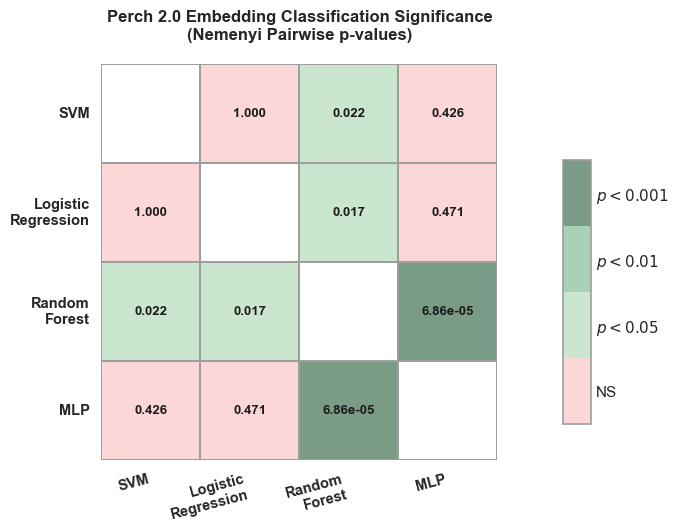

In [32]:
from evaluation.statistical_tests import evaluate_and_plot_linear_probe_algorithms
evaluate_and_plot_linear_probe_algorithms(per2_all_results, label_names=label_names)